# 🏦 Credit Risk Modelling — End-to-End Project
### Data Preparation · Model Development · Interpretation · Deployment

---

This notebook walks through a complete, production-style credit risk pipeline:

| Step | What we do |
|---|---|
| **1. Data Preparation** | Load borrower data, explore it, handle missing values |
| **2. Model Development** | Train Logistic Regression and Random Forest; compare metrics |
| **3. Interpretation** | Feature importance charts and SHAP explainability plots |
| **4. Deployment** | Save models with `joblib`; run a live Streamlit scoring app |

> **Dataset:** `data/borrowers.csv` — 1,000 synthetic loan applicants with traditional  
> financial features (income, credit score) *and* alternative data (mobile, UPI, e-commerce).

> Run `python notebooks/generate_data.py` once if the CSV does not yet exist.

---
## Part 1 — Data Preparation

Good models start with clean data. This section covers:
- Loading and inspecting the dataset
- Visualising class balance and feature distributions
- Handling missing values using scikit-learn imputers
- Scaling features ready for modelling

### 1.1 Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# scikit-learn — preprocessing and models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, roc_auc_score,
                              roc_curve, f1_score)

# Model persistence and explainability
import joblib
import shap

plt.rcParams['figure.dpi'] = 110
sns.set_style('whitegrid')
np.random.seed(42)
print('All libraries loaded.')


All libraries loaded.


### 1.2 Load & Inspect the Dataset

We load the CSV and immediately check its shape, data types, and how many values are missing.

In [2]:

df = pd.read_csv('borrowers.csv')

print('Shape:', df.shape)
print('Default rate: %.1f%%' % (df['default'].mean() * 100))
print()
df.head()


Shape: (1000, 15)
Default rate: 77.7%



,customer_id,annual_income,credit_score,debt_to_income,loan_amount,employment_years,missed_payments,num_credit_accounts,collateral_value,mobile_recharge_regularity,upi_txn_per_month,ecom_prepaid_ratio,bounced_transactions,salary_credit_regularity,default
0,1001,2369110,563,0.27,729892,25.0,9,7,1314870.0,0.98,32,0.55,4,0.62,1
1,1002,2379084,717,0.11,1751591,13.0,5,2,2903007.0,0.58,7,0.75,1,0.60,0
2,1003,1842743,395,0.87,1686091,12.0,1,14,554280.0,0.55,24,0.78,2,0.29,1
3,1004,260268,387,0.46,710327,26.0,1,6,1945548.0,0.33,45,0.32,3,0.68,1
4,1005,882180,377,0.81,1707153,3.0,4,1,2212292.0,0.73,8,0.72,6,0.79,1


In [3]:
# Check data types and missing values in one view
info = pd.DataFrame({
    'dtype':   df.dtypes,
    'missing': df.isnull().sum(),
    'pct_missing': (df.isnull().mean() * 100).round(1)
})
print(info[info['missing'] > 0])
print()
print('Total missing cells:', df.isnull().sum().sum())


                              dtype  missing  pct_missing
employment_years            float64       80          8.0
collateral_value            float64       80          8.0
mobile_recharge_regularity  float64       80          8.0
ecom_prepaid_ratio          float64       80          8.0
salary_credit_regularity    float64       80          8.0

Total missing cells: 400


### 1.3 Exploratory Data Analysis

Before touching the model, we visualise the data. Two questions we always ask:
1. Is the target class balanced?
2. Do the key features look different for defaulters vs non-defaulters?

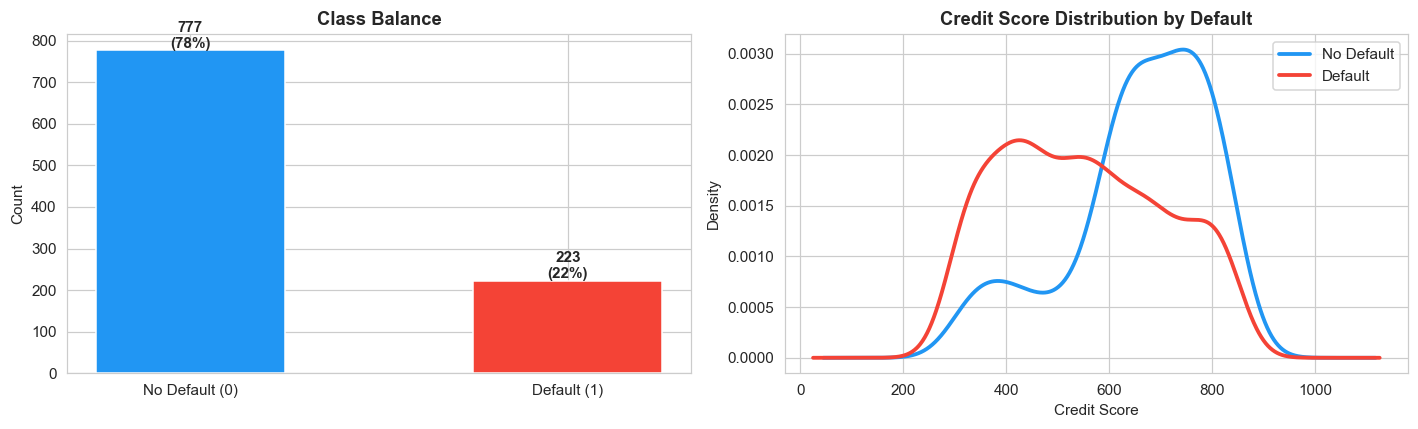

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# ── Left: class balance bar chart ────────────────────────────────────────
counts = df['default'].value_counts()
bars = axes[0].bar(['No Default (0)', 'Default (1)'], counts.values,
                   color=['#2196F3', '#F44336'], width=0.5, edgecolor='white')
for b, v in zip(bars, counts.values):
    axes[0].text(b.get_x() + b.get_width()/2, b.get_height() + 5,
                 '%d\n(%.0f%%)' % (v, v/len(df)*100),
                 ha='center', fontsize=10, fontweight='bold')
axes[0].set_title('Class Balance', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count')

# ── Right: credit score KDE split by default ─────────────────────────────
for cls, color, label in [(0, '#2196F3', 'No Default'), (1, '#F44336', 'Default')]:
    df[df['default'] == cls]['credit_score'].plot.kde(
        ax=axes[1], color=color, linewidth=2.5, label=label)
axes[1].set_title('Credit Score Distribution by Default', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Credit Score')
axes[1].legend()

plt.tight_layout()
plt.show()


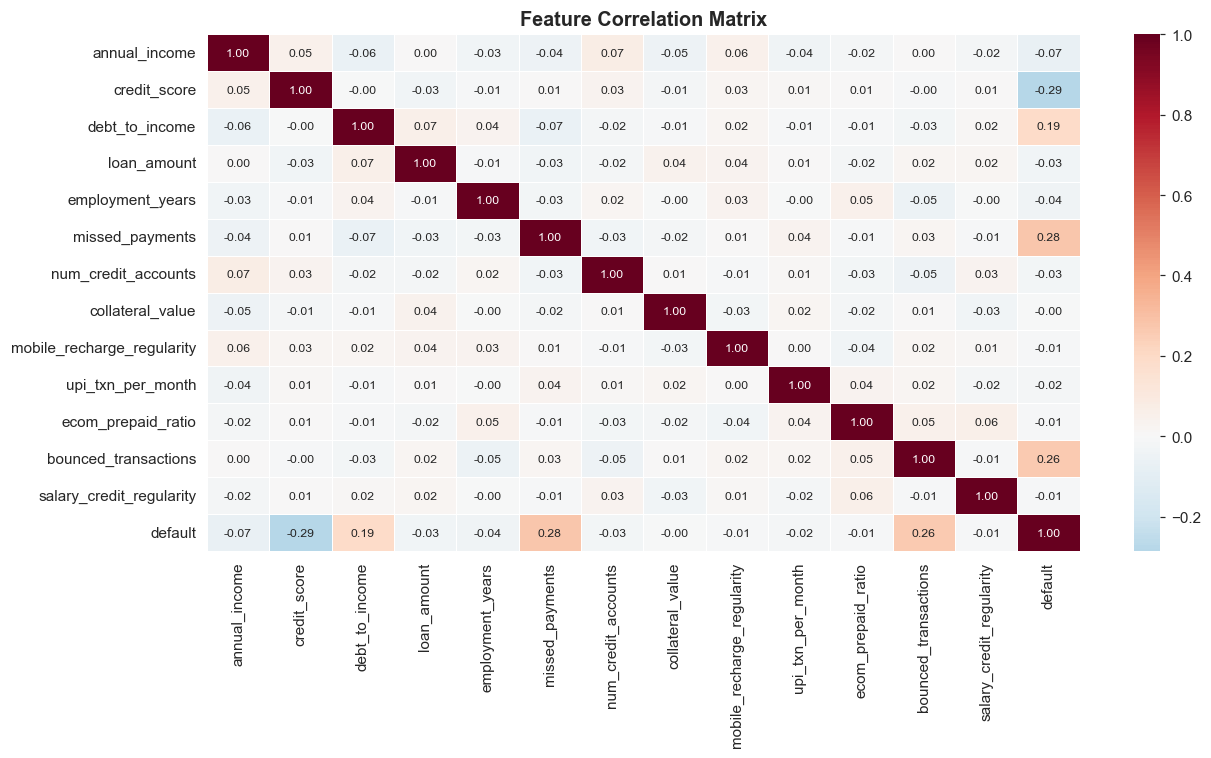

In [5]:
# ── Correlation heatmap (exclude customer_id and target) ─────────────────
# Helps spot multicollinearity and which features relate to default
feat_cols = [c for c in df.columns if c not in ['customer_id', 'default']]
corr = df[feat_cols + ['default']].corr()

fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title('Feature Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### 1.4 Handle Missing Values & Scale Features

We use a **scikit-learn Pipeline** — this is best practice because:
- It prevents *data leakage* (imputer/scaler fit only on training data)
- It packages preprocessing + model into one exportable object

**Strategy:** fill numeric missing values with the column median (robust to outliers).

In [6]:
# ── Define features and target ────────────────────────────────────────────
FEATURES = [
    'annual_income', 'credit_score', 'debt_to_income', 'loan_amount',
    'employment_years', 'missed_payments', 'num_credit_accounts',
    'collateral_value', 'mobile_recharge_regularity', 'upi_txn_per_month',
    'ecom_prepaid_ratio', 'bounced_transactions', 'salary_credit_regularity'
]

X = df[FEATURES]
y = df['default']

# ── Train / test split — stratified to preserve default rate ──────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print('Train:', X_train.shape, '| default rate: %.1f%%' % (y_train.mean()*100))
print('Test: ', X_test.shape,  '| default rate: %.1f%%' % (y_test.mean()*100))
print()
print('Missing values in X_train:', X_train.isnull().sum().sum())


Train: (800, 13) | default rate: 77.8%
Test:  (200, 13) | default rate: 77.5%

Missing values in X_train: 337


In [7]:
# ── Preprocessing pipeline (impute → scale) ──────────────────────────────
# SimpleImputer: replaces NaN with the median of that column
# StandardScaler: centres each feature to mean=0, std=1
#   (important for Logistic Regression; not needed for Random Forest but harmless)
preprocessor = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

# Fit on TRAIN only, then transform both sets
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc  = preprocessor.transform(X_test)      # no fit_transform here!

print('After preprocessing — any NaNs left?')
print('  Train:', np.isnan(X_train_proc).sum())
print('  Test: ', np.isnan(X_test_proc).sum())


After preprocessing — any NaNs left?
  Train: 0
  Test:  0


---
## Part 2 — Model Development

We train two models often used in credit risk:

| Model | Strengths | Weaknesses |
|---|---|---|
| **Logistic Regression** | Simple, fast, highly interpretable, well-understood by regulators | Assumes linear decision boundary |
| **Random Forest** | Captures non-linear patterns, robust to outliers, high accuracy | Less interpretable out of the box |

We compare them on three metrics:
- **AUC-ROC** — overall discrimination ability
- **F1-Score** — balance of precision and recall
- **Accuracy** — overall correct predictions

### 2.1 Logistic Regression

In [8]:
# Logistic Regression estimates P(default) as a sigmoid function of a
# linear combination of features. Highly interpretable — each coefficient
# tells us the direction and magnitude of each feature's effect.
# class_weight='balanced' compensates for class imbalance automatically.

lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr.fit(X_train_proc, y_train)

lr_pred  = lr.predict(X_test_proc)
lr_prob  = lr.predict_proba(X_test_proc)[:, 1]   # probability of default
lr_auc   = roc_auc_score(y_test, lr_prob)
lr_f1    = f1_score(y_test, lr_pred)
lr_acc   = lr.score(X_test_proc, y_test)

print('Logistic Regression')
print('  AUC-ROC:  %.4f' % lr_auc)
print('  F1 Score: %.4f' % lr_f1)
print('  Accuracy: %.4f' % lr_acc)
print()
print(classification_report(y_test, lr_pred, target_names=['No Default', 'Default']))


Logistic Regression
  AUC-ROC:  0.8314
  F1 Score: 0.8561
  Accuracy: 0.7950

              precision    recall  f1-score   support

  No Default       0.53      0.82      0.64        45
     Default       0.94      0.79      0.86       155

    accuracy                           0.80       200
   macro avg       0.73      0.80      0.75       200
weighted avg       0.85      0.80      0.81       200



### 2.2 Random Forest

In [9]:
# Random Forest trains hundreds of decision trees on random subsets of data
# and features, then averages their predictions. This reduces overfitting
# and typically outperforms a single tree significantly.
# n_estimators=200: number of trees — more trees = more stable but slower

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,             # limits tree depth to prevent overfitting
    class_weight='balanced', # handles class imbalance
    random_state=42,
    n_jobs=-1                # use all CPU cores
)
rf.fit(X_train_proc, y_train)

rf_pred = rf.predict(X_test_proc)
rf_prob = rf.predict_proba(X_test_proc)[:, 1]
rf_auc  = roc_auc_score(y_test, rf_prob)
rf_f1   = f1_score(y_test, rf_pred)
rf_acc  = rf.score(X_test_proc, y_test)

print('Random Forest')
print('  AUC-ROC:  %.4f' % rf_auc)
print('  F1 Score: %.4f' % rf_f1)
print('  Accuracy: %.4f' % rf_acc)
print()
print(classification_report(y_test, rf_pred, target_names=['No Default', 'Default']))


Random Forest
  AUC-ROC:  0.8817
  F1 Score: 0.9497
  Accuracy: 0.9200

              precision    recall  f1-score   support

  No Default       0.89      0.73      0.80        45
     Default       0.93      0.97      0.95       155

    accuracy                           0.92       200
   macro avg       0.91      0.85      0.88       200
weighted avg       0.92      0.92      0.92       200



### 2.3 Model Comparison

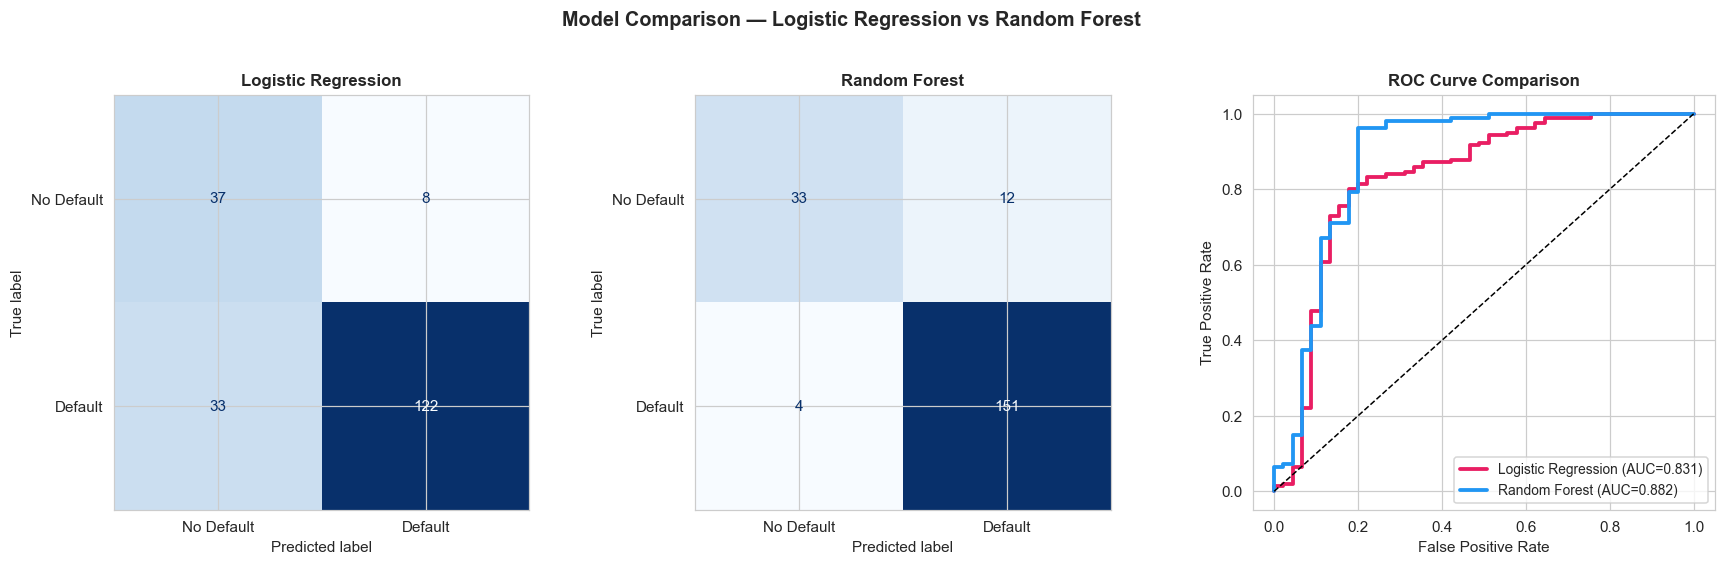

              Model  AUC-ROC  F1 Score  Accuracy
Logistic Regression   0.8314    0.8561     0.795
      Random Forest   0.8817    0.9497     0.920


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Left & Centre: Confusion Matrices ────────────────────────────────────
for ax, pred, title in [
    (axes[0], lr_pred, 'Logistic Regression'),
    (axes[1], rf_pred, 'Random Forest')
]:
    ConfusionMatrixDisplay(
        confusion_matrix(y_test, pred),
        display_labels=['No Default', 'Default']
    ).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title, fontsize=11, fontweight='bold')

# ── Right: ROC Curves ─────────────────────────────────────────────────────
for prob, auc, label, color in [
    (lr_prob, lr_auc, 'Logistic Regression', '#E91E63'),
    (rf_prob, rf_auc, 'Random Forest',       '#2196F3')
]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    axes[2].plot(fpr, tpr, linewidth=2.5, color=color,
                 label='%s (AUC=%.3f)' % (label, auc))

axes[2].plot([0,1],[0,1],'k--', linewidth=1)
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].set_title('ROC Curve Comparison', fontsize=11, fontweight='bold')
axes[2].legend(fontsize=9)

plt.suptitle('Model Comparison — Logistic Regression vs Random Forest',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────
comparison = pd.DataFrame({
    'Model':    ['Logistic Regression', 'Random Forest'],
    'AUC-ROC':  [round(lr_auc,4), round(rf_auc,4)],
    'F1 Score': [round(lr_f1,4),  round(rf_f1,4)],
    'Accuracy': [round(lr_acc,4), round(rf_acc,4)]
})
print(comparison.to_string(index=False))


---
## Part 3 — Model Interpretation

Regulators and credit committees need to understand *why* a model makes a decision.  
We use two complementary tools:

- **Feature Importance** (Random Forest built-in) — which features matter most overall
- **SHAP values** — how each feature pushed a *specific prediction* up or down

> SHAP (SHapley Additive exPlanations) is the gold standard for model explainability.
> Each SHAP value answers: *'How much did this feature contribute to this borrower's default probability?'*

### 3.1 Random Forest Feature Importance

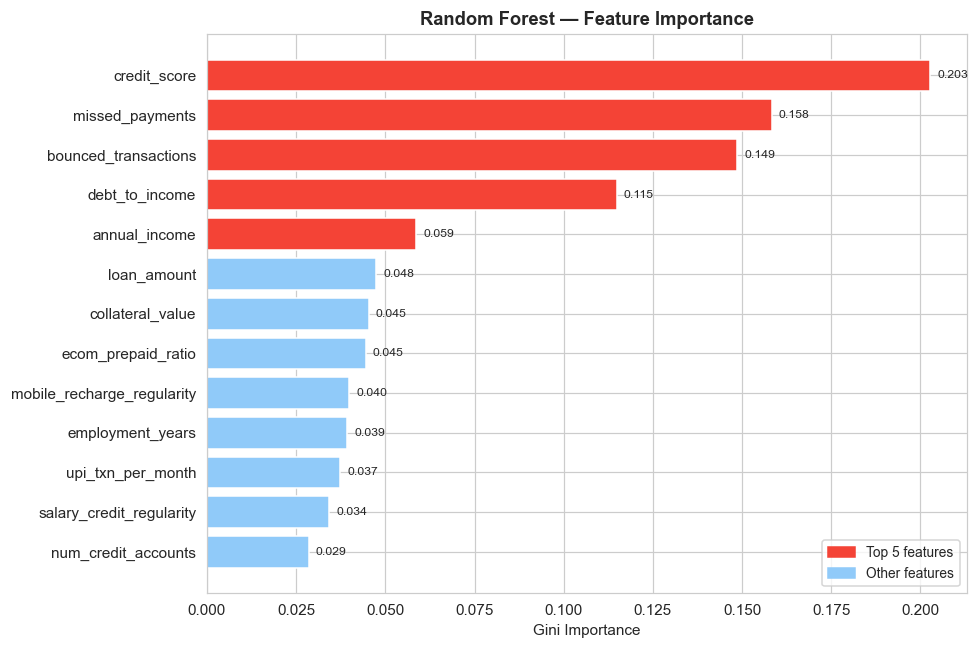

In [11]:
# Feature importance = total impurity reduction caused by each feature
# across all trees, normalised to sum to 1.0

importance_df = pd.DataFrame({
    'feature':    FEATURES,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=True)

# Colour: top 5 features in red, rest in blue
top5 = importance_df.nlargest(5, 'importance')['feature'].tolist()
colors = ['#F44336' if f in top5 else '#90CAF9' for f in importance_df['feature']]

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(importance_df['feature'], importance_df['importance'],
               color=colors, edgecolor='white')
for bar, val in zip(bars, importance_df['importance']):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            '%.3f' % val, va='center', fontsize=8)
ax.set_xlabel('Gini Importance')
ax.set_title('Random Forest — Feature Importance', fontsize=12, fontweight='bold')
red_p  = mpatches.Patch(color='#F44336', label='Top 5 features')
blue_p = mpatches.Patch(color='#90CAF9', label='Other features')
ax.legend(handles=[red_p, blue_p], fontsize=9)
plt.tight_layout()
plt.show()


### 3.2 Logistic Regression Coefficients

For Logistic Regression, the coefficients directly show the direction and strength of each feature's effect.
- **Positive coefficient** → higher value increases default probability
- **Negative coefficient** → higher value decreases default probability

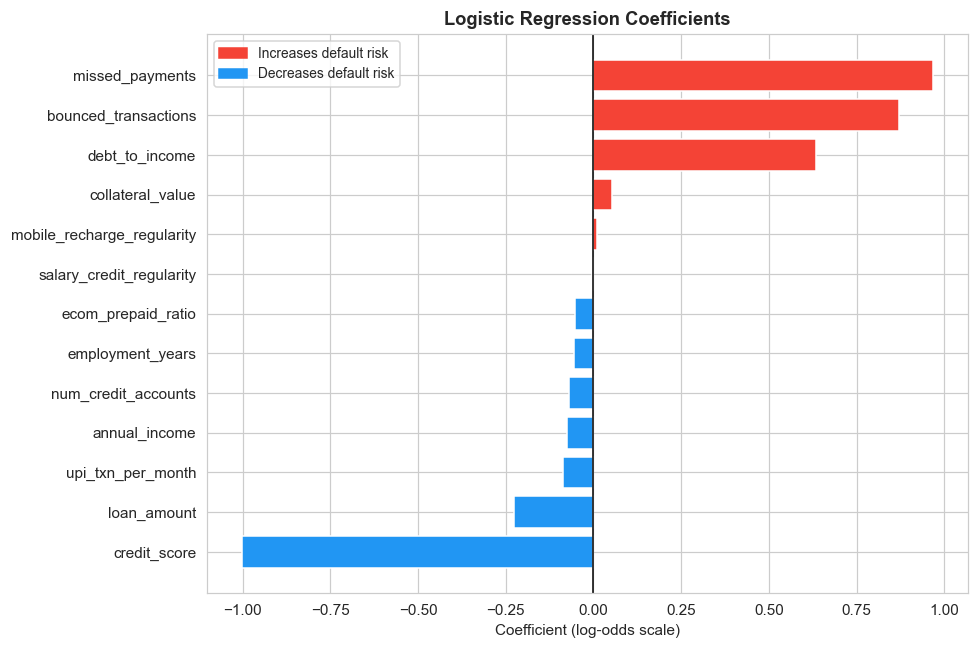

In [12]:
coef_df = pd.DataFrame({
    'feature':     FEATURES,
    'coefficient': lr.coef_[0]
}).sort_values('coefficient')

colors = ['#F44336' if c > 0 else '#2196F3' for c in coef_df['coefficient']]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(coef_df['feature'], coef_df['coefficient'], color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('Coefficient (log-odds scale)')
ax.set_title('Logistic Regression Coefficients', fontsize=12, fontweight='bold')
red_p  = mpatches.Patch(color='#F44336', label='Increases default risk')
blue_p = mpatches.Patch(color='#2196F3', label='Decreases default risk')
ax.legend(handles=[red_p, blue_p], fontsize=9)
plt.tight_layout()
plt.show()


### 3.3 SHAP Explainability

SHAP gives us two key views:
1. **Summary Plot (beeswarm)** — overall impact of every feature across all test samples
2. **Waterfall Plot** — a single borrower's prediction broken down feature by feature

In [13]:
# SHAP TreeExplainer is optimised for tree-based models like Random Forest
# We use a sample of 200 test points to keep computation fast

sample_idx = np.random.choice(len(X_test_proc), size=200, replace=False)
X_sample   = X_test_proc[sample_idx]

explainer   = shap.TreeExplainer(rf)
# sv has shape (n_samples, n_features, n_classes) for classifiers
sv          = explainer(X_sample)
# Extract SHAP values for class 1 (Default) only
sv_default  = sv[..., 1]    # shape: (n_samples, n_features)

print('SHAP values computed for %d test samples.' % len(X_sample))
print('Shape (samples x features):', sv_default.values.shape)


SHAP values computed for 200 test samples.
Shape (samples x features): (200, 13)


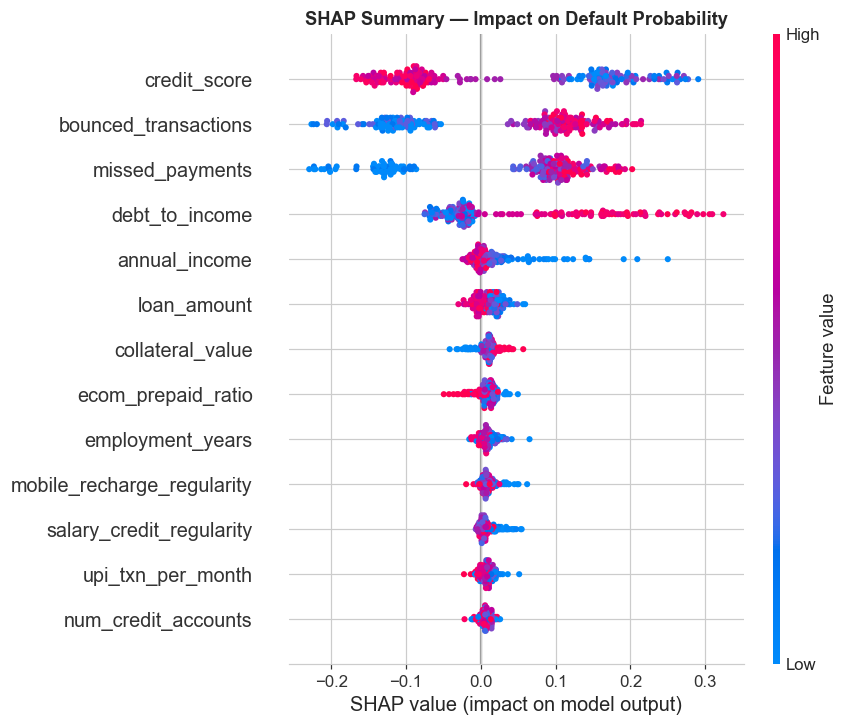

In [14]:
# ── SHAP Summary Plot (beeswarm) ─────────────────────────────────────────
# Each dot = one borrower. Colour = feature value (red=high, blue=low).
# Position on x-axis = SHAP value (how much it pushed the prediction)

plt.figure(figsize=(10, 7))
shap.summary_plot(
    sv_default.values,
    X_sample,
    feature_names=FEATURES,
    show=False
)
plt.title('SHAP Summary — Impact on Default Probability', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


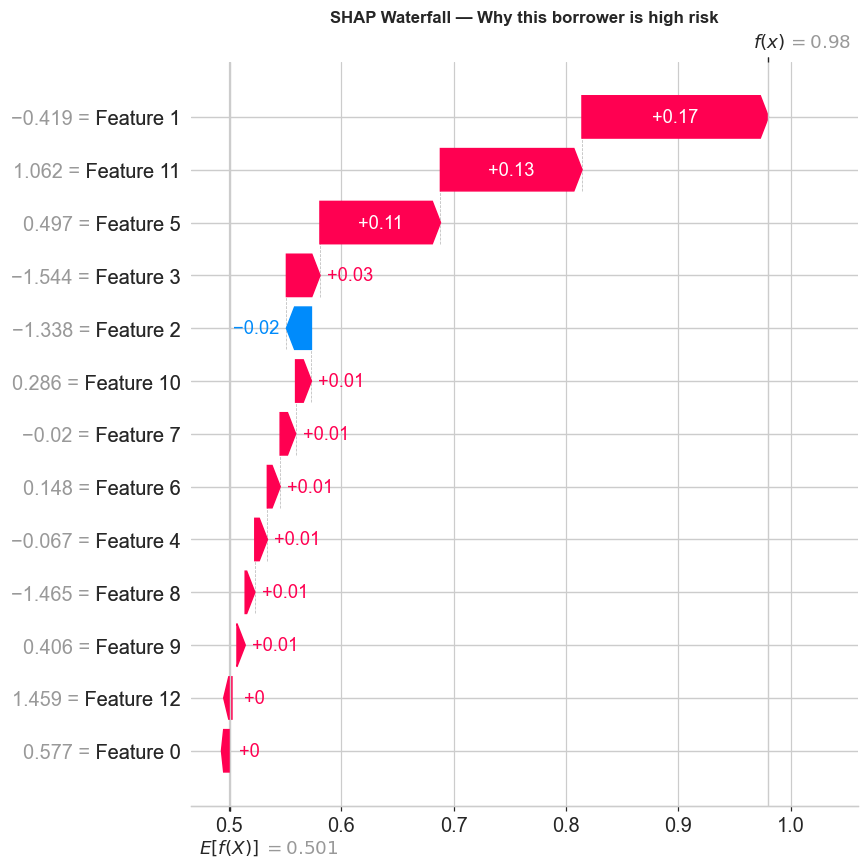

Borrower predicted default probability: 98.0%


In [15]:
# ── SHAP Waterfall Plot — single borrower explanation ────────────────────
# Pick the test borrower with the highest predicted default probability
# This shows exactly which features drove THAT specific decision

highest_risk_idx = np.argmax(rf_prob)
single_sv = explainer(X_test_proc[highest_risk_idx:highest_risk_idx+1])
single_sv_default = single_sv[..., 1]   # class 1 (Default)

plt.figure(figsize=(10, 6))
shap.plots.waterfall(single_sv_default[0], max_display=13, show=False)
plt.title('SHAP Waterfall — Why this borrower is high risk', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

print('Borrower predicted default probability: %.1f%%' % (rf_prob[highest_risk_idx]*100))


---
## Part 4 — Deployment Simulation

Once models are trained, we need to:
1. **Save** them to disk so they can be loaded without retraining
2. **Load** them in a web app that scores new borrowers in real time

We use `joblib` for serialisation — it handles scikit-learn objects efficiently.
The Streamlit app (`app.py`) reads these saved files.

### 4.1 Save Models with joblib

In [18]:
import os
os.makedirs('models', exist_ok=True)

# Save the preprocessing pipeline — must be saved alongside the model
# so new data is transformed identically to training data
joblib.dump(preprocessor,   'models/preprocessor.pkl')

# For the Streamlit app we wrap preprocessor + model into one pipeline
# so the app only needs to call .predict_proba(raw_features)
from sklearn.pipeline import Pipeline as SKPipeline

lr_pipeline = SKPipeline([('prep', preprocessor), ('model', lr)])
rf_pipeline = SKPipeline([('prep', preprocessor), ('model', rf)])

joblib.dump(lr_pipeline, 'models/logistic_regression.pkl')
joblib.dump(rf_pipeline, 'models/random_forest.pkl')

print('Saved:')
for f in os.listdir('models'):
    size = os.path.getsize('models/' + f) / 1024
    print('  models/%s  (%.0f KB)' % (f, size))


Saved:
  models/logistic_regression.pkl  (3 KB)
  models/preprocessor.pkl  (2 KB)
  models/random_forest.pkl  (1989 KB)


### 4.2 Reload & Verify

Always verify that a freshly loaded model gives identical predictions — a basic sanity check.

In [17]:
# Load models from disk (simulating what the Streamlit app does)
lr_loaded = joblib.load('models/logistic_regression.pkl')
rf_loaded = joblib.load('models/random_forest.pkl')

# Predict on raw (un-preprocessed) test data — the pipeline handles it
lr_reload_prob = lr_loaded.predict_proba(X_test)[:, 1]
rf_reload_prob = rf_loaded.predict_proba(X_test)[:, 1]

# Verify predictions are identical to the original (should both be True)
print('LR predictions match:', np.allclose(lr_reload_prob, lr_prob))
print('RF predictions match:', np.allclose(rf_reload_prob, rf_prob))
print()
print('Models verified. Ready for deployment.')


LR predictions match: True
RF predictions match: True

Models verified. Ready for deployment.


### 4.3 Launch the Streamlit App

The file `app.py` in the project root contains a fully working Streamlit web app.  
It loads the saved models and lets you score a borrower interactively via sidebar sliders.

**To run it, open a terminal in the project folder and run:**

```bash
streamlit run app.py
```

The app will open in your browser at `http://localhost:8501`.

> The app reads feature values from sliders, passes them through the saved pipeline  
> (imputer → scaler → model), and displays the predicted default probability and risk band.

In [18]:
# Preview what the app sees: score a single hand-crafted borrower ──────────
# This is exactly what happens when you move a slider in the Streamlit UI

sample_borrower = pd.DataFrame([{
    'annual_income':              850_000,
    'credit_score':               720,
    'debt_to_income':             0.28,
    'loan_amount':                300_000,
    'employment_years':           6,
    'missed_payments':            0,
    'num_credit_accounts':        4,
    'collateral_value':           800_000,
    'mobile_recharge_regularity': 0.91,
    'upi_txn_per_month':          18,
    'ecom_prepaid_ratio':         0.82,
    'bounced_transactions':       0,
    'salary_credit_regularity':   0.95
}])

lr_pd = lr_loaded.predict_proba(sample_borrower)[0][1]
rf_pd = rf_loaded.predict_proba(sample_borrower)[0][1]

print('Sample Borrower Scoring')
print('  Logistic Regression PD: %.1f%%' % (lr_pd * 100))
print('  Random Forest PD:       %.1f%% ' % (rf_pd * 100))
print('  Ensemble Average PD:    %.1f%%' % ((lr_pd + rf_pd) / 2 * 100))
print()
avg = (lr_pd + rf_pd) / 2
band = 'LOW RISK — Approve' if avg < 0.2 else ('MEDIUM RISK — Review' if avg < 0.5 else 'HIGH RISK — Reject')
print('  Risk Band:', band)


Sample Borrower Scoring
  Logistic Regression PD: 3.5%
  Random Forest PD:       21.2% 
  Ensemble Average PD:    12.4%

  Risk Band: LOW RISK — Approve


---
## ✅ Project Summary

| Part | Key tools used | Output |
|---|---|---|
| Data Preparation | `pandas`, `SimpleImputer`, `StandardScaler`, `Pipeline` | Clean feature matrix |
| Model Development | `LogisticRegression`, `RandomForestClassifier` | AUC, F1, ROC curves |
| Interpretation | `feature_importances_`, `shap.TreeExplainer` | Importance charts, SHAP plots |
| Deployment | `joblib`, `streamlit` | `.pkl` model files, live scoring app |

### Files in this project

```
credit_project/
├── models/                  # created by the notebook
│   ├── preprocessor.pkl
│   ├── logistic_regression.pkl
│   └── random_forest.pkl
├── notebooks/
│   └── credit_risk.ipynb    # this notebook
├── app.py                   # Streamlit scoring app
└── requirements.txt         # Python dependencies
```